In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.tree import DecisionTreeRegressor

In [3]:
df = pd.read_csv("6_india_housing_prices.csv")
df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [37]:
df.shape

(250000, 21)

## EDA

In [4]:
df.isnull().sum()

ID                                0
State                             0
City                              0
Locality                          0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Price_per_SqFt                    0
Year_Built                        0
Furnished_Status                  0
Floor_No                          0
Total_Floors                      0
Age_of_Property                   0
Nearby_Schools                    0
Nearby_Hospitals                  0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
Amenities                         0
Facing                            0
Owner_Type                        0
Availability_Status               0
dtype: int64

In [4]:
df.dtypes

ID                                  int64
State                              object
City                               object
Locality                           object
Property_Type                      object
BHK                                 int64
Size_in_SqFt                        int64
Price_in_Lakhs                    float64
Price_per_SqFt                    float64
Year_Built                          int64
Furnished_Status                   object
Floor_No                            int64
Total_Floors                        int64
Age_of_Property                     int64
Nearby_Schools                      int64
Nearby_Hospitals                    int64
Public_Transport_Accessibility     object
Parking_Space                      object
Security                           object
Amenities                          object
Facing                             object
Owner_Type                         object
Availability_Status                object
dtype: object

In [5]:
df.describe()

,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,125000.500000,2.999396,2749.813216,254.586854,0.130597,2006.520012,14.966800,15.503004,18.479988,5.499860,5.498016
std,72168.927986,1.415521,1300.606954,141.349921,0.130747,9.808575,8.948047,8.671618,9.808575,2.878639,2.871860
min,1.000000,1.000000,500.000000,10.000000,0.000000,1990.000000,0.000000,1.000000,2.000000,1.000000,1.000000
25%,62500.750000,2.000000,1623.000000,132.550000,0.050000,1998.000000,7.000000,8.000000,10.000000,3.000000,3.000000
50%,125000.500000,3.000000,2747.000000,253.870000,0.090000,2007.000000,15.000000,15.000000,18.000000,5.000000,5.000000
75%,187500.250000,4.000000,3874.000000,376.880000,0.160000,2015.000000,23.000000,23.000000,27.000000,8.000000,8.000000
max,250000.000000,5.000000,5000.000000,500.000000,0.990000,2023.000000,30.000000,30.000000,35.000000,10.000000,10.000000


## Pre-Processing

####  Dropping `ID` column since it's irrelevant 

In [7]:
df.drop('ID', axis=1, inplace=True)

#### Dropping `Locality` column since it's doesn't containg meaningful address

In [8]:
df.drop('Locality', axis=1, inplace=True)

#### Using Ordinal Encoder to Encode Ordinal Values

In [9]:
ordinal_columns = ['Property_Type', 'Furnished_Status', 'Public_Transport_Accessibility', 'Facing', 'Security']

categories = [['Apartment', 'Independent House', 'Villa'],
              ['Unfurnished', 'Semi-furnished', 'Furnished'],
              ['Low', 'Medium', 'High'],
              ['South', 'East', 'West', 'North'],  
              ['No', 'Yes']]

encoder = OrdinalEncoder(categories=categories)
df[ordinal_columns] = encoder.fit_transform(df[ordinal_columns])

#### Separating Categorical and Numerical columns

In [10]:
categorical_col = [column for column in df.columns if df[column].dtype == 'object']
numerical_col = [column for column in df.columns if df[column].dtype != 'object']

In [11]:
len(categorical_col), len(numerical_col)

(6, 15)

#### Lower cap strings for better accessibility

In [12]:
for column in categorical_col:
    df[column] = df[column].str.lower()

#### Checking Correlation

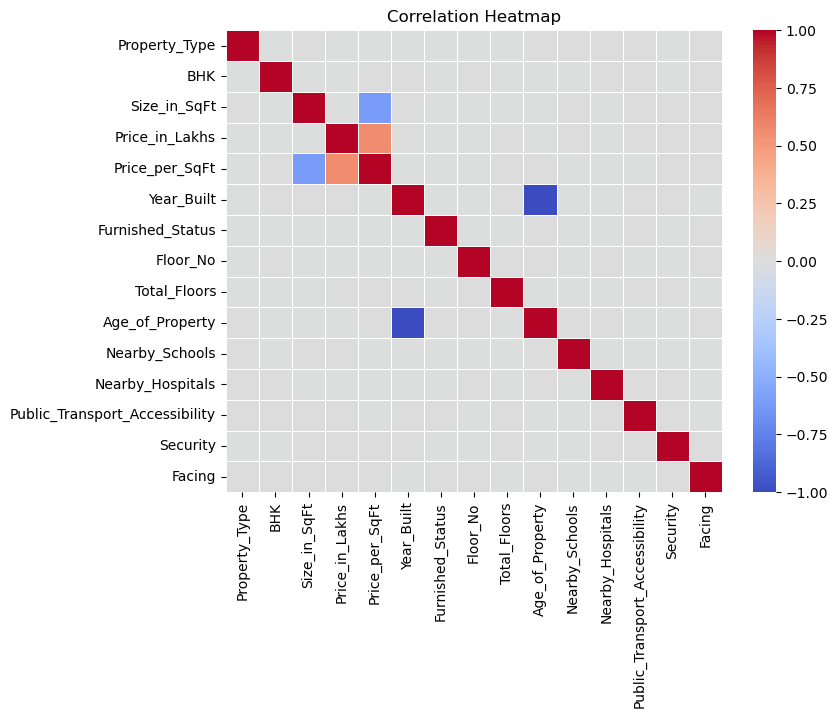

In [14]:
correlation_matrix = df[numerical_col].corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

#### Splitting Dataset and Picking Out Smaller Sample

Reducing **Number of rows** to speed up training due to low compute power

In [16]:
# Randomly sample 40% of the data
df_sampled = df.sample(frac=0.4, random_state=1)

In [17]:
df_sampled

,State,City,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,Floor_No,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
240208,karnataka,bangalore,0.0,5,3342,108.05,0.03,2013,2.0,14,...,12,4,1,1.0,no,0.0,"playground, pool, clubhouse, gym",3.0,owner,ready_to_move
18744,chhattisgarh,bilaspur,2.0,2,4417,25.74,0.01,2001,2.0,5,...,24,7,5,1.0,yes,1.0,"gym, pool, garden",0.0,builder,ready_to_move
207175,chhattisgarh,raipur,0.0,4,1850,41.04,0.02,2014,2.0,27,...,11,2,9,2.0,yes,1.0,garden,0.0,owner,under_construction
18669,uttarakhand,haridwar,0.0,1,3204,249.55,0.08,2014,0.0,18,...,11,3,7,0.0,no,1.0,"playground, clubhouse, pool, garden",0.0,owner,ready_to_move
189086,tamil nadu,coimbatore,0.0,1,4646,54.48,0.01,2008,1.0,18,...,17,4,8,1.0,yes,0.0,"playground, garden, clubhouse, pool, gym",2.0,builder,under_construction
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217635,assam,guwahati,2.0,5,3030,305.73,0.10,2018,2.0,7,...,7,9,9,1.0,no,0.0,playground,2.0,broker,under_construction
154802,punjab,ludhiana,2.0,4,4784,483.02,0.10,2007,2.0,16,...,18,9,4,1.0,no,0.0,"playground, garden",2.0,broker,ready_to_move
246477,uttar pradesh,noida,0.0,1,2254,436.77,0.19,2006,1.0,30,...,19,10,9,1.0,yes,1.0,"garden, gym, clubhouse, playground",0.0,builder,ready_to_move
41107,jharkhand,ranchi,0.0,5,3136,296.59,0.09,1994,0.0,24,...,31,3,5,2.0,no,1.0,garden,0.0,owner,under_construction


In [18]:
X = df_sampled.drop('Price_in_Lakhs', axis=1)  
y = df_sampled['Price_in_Lakhs']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)


In [19]:
len(X_test), len(X_train)

(20000, 80000)

#### Encoding Categorical Variables
- DictVectorizer automatically handles categorical columns

In [20]:
train_dicts = X_train.to_dict(orient='records') # using resampled data as our train feature
test_dicts = X_test.to_dict(orient='records')

In [21]:
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)
X_test = dv.transform(test_dicts)

## Training The Model
- Training Using Different Models and Evaluating Their Results
- Helper function and list to evaluate models and store scores

In [24]:
model_results = []

def evaluate_model(y, y_pred):
    mae = mean_absolute_error(y, y_pred)
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, y_pred)
    
    return mae, mse, rmse, r2

In [34]:
model_results

[{'Model': 'Linear Regression',
  'MAE': 81.74841869879782,
  'MSE': 10364.252021418084,
  'RMSE': 101.80497051430291,
  'R2': 0.48763300030592605},
 {'Model': 'Linear Regression',
  'MAE': 81.74841869879782,
  'MSE': 10364.252021418084,
  'RMSE': 101.80497051430291,
  'R2': 0.48763300030592605},
 {'Model': 'Linear Regression',
  'MAE': 81.74841869879782,
  'MSE': 10364.252021418084,
  'RMSE': 101.80497051430291,
  'R2': 0.48763300030592605}]

## Linear Regression

In [27]:
model = LinearRegression(n_jobs=-1)
model.fit(X_train, y_train)

LinearRegression(n_jobs=-1)

In [28]:
y_pred = model.predict(X_test)
mae, mse, rmse, r2 = evaluate_model(y_test, y_pred)
mae, mse, rmse, r2

(81.74841869879782,
 10364.252021418084,
 101.80497051430291,
 0.48763300030592605)

In [30]:
model_results.append({
    "Model": "Linear Regression",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2": r2
})

In [36]:
model_results

[{'Model': 'Linear Regression',
  'MAE': 81.74841869879782,
  'MSE': 10364.252021418084,
  'RMSE': 101.80497051430291,
  'R2': 0.48763300030592605},
 {'Model': 'Linear Regression',
  'MAE': 81.74841869879782,
  'MSE': 10364.252021418084,
  'RMSE': 101.80497051430291,
  'R2': 0.48763300030592605},
 {'Model': 'Linear Regression',
  'MAE': 81.74841869879782,
  'MSE': 10364.252021418084,
  'RMSE': 101.80497051430291,
  'R2': 0.48763300030592605},
 {'Model': 'Linear Regression',
  'MAE': 81.74841869879782,
  'MSE': 10364.252021418084,
  'RMSE': 101.80497051430291,
  'R2': 0.48763300030592605}]